# Two-Stage Emotion Detection System

This notebook implements a two-stage emotion detection system:
- **Stage 1**: Detect faces using pre-trained YOLO
- **Stage 2**: Classify emotions from detected face regions

---

## 1. Import Libraries

In [1]:
import torch
from ultralytics import YOLO
import cv2
import numpy as np
from pathlib import Path
from PIL import Image
import shutil
from IPython.display import display, Image as IPImage, clear_output
import matplotlib.pyplot as plt

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 2. TwoStageEmotionDetector Class

In [ ]:
class TwoStageEmotionDetector:
    """
    Two-stage emotion detection system:
    Stage 1: Detect faces using pre-trained YOLO
    Stage 2: Classify emotions from detected face regions
    """
    
    def __init__(self, face_model='yolov8m-face.pt', emotion_model=None, device='cuda'):
        """
        Initialize the two-stage detector.
        
        Args:
            face_model: Pre-trained face detection model path
            emotion_model: Trained emotion classifier path (None for training mode)
            device: Computing device ('cuda' or 'cpu')
        """
        self.device = device if torch.cuda.is_available() else 'cpu'
        print(f"Using device: {self.device}")
        
        # Load face detection model
        print("Loading face detection model...")
        try:
            self.face_detector = YOLO(face_model)
            print(f"✓ Face detector loaded: {face_model}")
        except:
            print(f"⚠ {face_model} not found, falling back to yolov8n.pt")
            print("  For better results, download yolov8m-face.pt from:")
            print("  https://github.com/akanametov/yolov8-face")
            self.face_detector = YOLO('yolov8n.pt')
        
        # Load or initialize emotion classifier
        if emotion_model and Path(emotion_model).exists():
            self.emotion_classifier = YOLO(emotion_model)
            print(f"✓ Emotion classifier loaded: {emotion_model}")
        else:
            self.emotion_classifier = YOLO('yolov8m-cls.pt')
            print("✓ Emotion classifier initialized for training")
    
    def train_emotion_classifier(self, dataset_dir, epochs=20, imgsz=224, batch=32, patience=15):
        """
        Train the emotion classification model.
        """
        print(f"\n{'='*60}")
        print("Training Emotion Classifier")
        print(f"{'='*60}\n")
        
        results = self.emotion_classifier.train(
            data=dataset_dir,
            epochs=epochs,
            imgsz=imgsz,
            batch=batch,
            device=self.device,
            patience=patience,
            save=True,
            plots=True,
            project='emotion_runs',
            name='emotion_classifier'
        )
        
        print("\n✓ Training completed!")
        
        # Automatically copy best model to root directory
        best_model_path = Path('emotion_runs/emotion_classifier/weights/best.pt')
        root_model_path = Path('best_emotion_model.pt')
        
        if best_model_path.exists():
            shutil.copy2(best_model_path, root_model_path)
            print(f"✓ Best model automatically saved to: {root_model_path.absolute()}")
        
        return results
    
    def validate_emotion_classifier(self, dataset_dir):
        """Validate the trained emotion classifier."""
        print("\nValidating emotion classifier...")
        return self.emotion_classifier.val(data=dataset_dir)
    
    def detect_and_classify(self, image_path, conf_face=0.5, conf_emotion=0.3, 
                           save_output=False, output_path=None):
        """
        Perform two-stage emotion detection on an image.
        
        Returns:
            annotated_img: Image with bounding boxes and labels
            emotions_detected: List of detected emotions with metadata
        """
        # Load image
        if isinstance(image_path, str):
            img = cv2.imread(image_path)
            if img is None:
                print(f"Error: Could not read image {image_path}")
                return None, []
        else:
            img = image_path
        
        # Stage 1: Detect faces
        face_results = self.face_detector(img, conf=conf_face, verbose=False)
        
        # Check if any faces detected
        if (face_results is None or len(face_results) == 0 or 
            face_results[0].boxes is None or len(face_results[0].boxes) == 0):
            return img, []
        
        # Stage 2: Classify emotion for each detected face
        emotions_detected = []
        annotated_img = img.copy()
        
        for box in face_results[0].boxes:
            # Extract face region
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            face_crop = img[y1:y2, x1:x2]
            
            if face_crop.size == 0:
                continue
            
            # Classify emotion
            emotion_results = self.emotion_classifier(face_crop, conf=conf_emotion, verbose=False)
            
            if len(emotion_results) > 0:
                probs = emotion_results[0].probs
                top_class = probs.top1
                confidence = probs.top1conf.item()
                emotion = emotion_results[0].names[top_class]
                
                emotions_detected.append({
                    'emotion': emotion,
                    'confidence': confidence,
                    'bbox': [x1, y1, x2, y2]
                })
                
                # Annotate image
                color = self._get_emotion_color(emotion)
                cv2.rectangle(annotated_img, (x1, y1), (x2, y2), color, 2)
                
                # Draw label with background
                label = f"{emotion}: {confidence:.2%}"
                (label_w, label_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                cv2.rectangle(annotated_img, (x1, y1 - label_h - 10), (x1 + label_w, y1), color, -1)
                cv2.putText(annotated_img, label, (x1, y1 - 5),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        
        # Print results
        print(f"\nDetected {len(emotions_detected)} face(s):")
        for i, result in enumerate(emotions_detected, 1):
            print(f"  Face {i}: {result['emotion']} ({result['confidence']:.2%})")
        
        # Save output if requested
        if save_output and output_path:
            cv2.imwrite(output_path, annotated_img)
            print(f"\n✓ Saved annotated image to: {output_path}")
        
        return annotated_img, emotions_detected
    
    def process_video(self, video_source, output_path=None, conf_face=0.5, conf_emotion=0.3):
        """
        Process video file or webcam stream for emotion detection.
        """
        # Open video source
        if video_source == 'webcam':
            video_source = 0
        
        cap = cv2.VideoCapture(video_source)
        
        if not cap.isOpened():
            print(f"Error: Could not open video source {video_source}")
            return
        
        # Setup video writer if output requested
        if output_path:
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            fps = int(cap.get(cv2.CAP_PROP_FPS)) or 30
            width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
        
        print("\nProcessing video... Press 'q' to quit")
        frame_count = 0
        
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            
            frame_count += 1
            
            # Process frame
            annotated_frame, emotions = self.detect_and_classify(
                frame, conf_face=conf_face, conf_emotion=conf_emotion
            )
            
            # Always use the frame (annotated or original)
            display_frame = annotated_frame if annotated_frame is not None else frame
            
            # Add frame info overlay
            info_text = f"Frame: {frame_count} | Faces: {len(emotions) if emotions else 0}"
            cv2.putText(display_frame, info_text, (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            
            # Display frame
            cv2.imshow('Emotion Detection', display_frame)
            
            # Save frame if recording
            if output_path:
                out.write(display_frame)
            
            # Check for quit command (MUST be after imshow)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
        
        # Cleanup
        cap.release()
        if output_path:
            out.release()
        cv2.destroyAllWindows()
        print(f"\n✓ Video processing completed! Processed {frame_count} frames")
    
    def _get_emotion_color(self, emotion):
        """Map emotions to BGR colors for visualization."""
        colors = {
            'angry': (0, 0, 255),        # Red
            'disgusted': (0, 128, 128),  # Teal
            'fearful': (128, 0, 128),    # Purple
            'happy': (0, 255, 0),        # Green
            'neutral': (128, 128, 128),  # Gray
            'sad': (255, 0, 0),          # Blue
            'surprised': (0, 255, 255),  # Yellow
            'nothing': (200, 200, 200)   # Light gray
        }
        return colors.get(emotion.lower(), (255, 255, 255))
    
    def export_emotion_model(self, format='onnx'):
        """Export emotion classifier to different formats."""
        print(f"Exporting emotion classifier to {format}...")
        self.emotion_classifier.export(format=format)
        
        # Copy exported model to root directory
        if format == 'onnx':
            onnx_path = Path('emotion_runs/emotion_classifier/weights/best.onnx')
            root_onnx_path = Path('best_emotion_model.onnx')
            if onnx_path.exists():
                shutil.copy2(onnx_path, root_onnx_path)
                print(f"✓ ONNX model saved to: {root_onnx_path.absolute()}")
        
        print("✓ Export completed!")


def check_trained_model():
    """Check if a trained emotion model already exists."""
    possible_paths = [
        Path('best_emotion_model.pt'),
        Path('emotion_runs/emotion_classifier/weights/best.pt'),
    ]
    
    for path in possible_paths:
        if path.exists():
            print(f"\n✓ Found trained model: {path.absolute()}")
            return str(path)
    
    return None


print("✓ TwoStageEmotionDetector class defined!")

✓ TwoStageEmotionDetector class defined!


## 3. Check for Existing Model

In [3]:
print("="*60)
print("TWO-STAGE EMOTION DETECTION SYSTEM")
print("="*60 + "\n")

trained_model_path = check_trained_model()

if trained_model_path:
    print("\n" + "="*60)
    print("TRAINED MODEL FOUND - SKIPPING TRAINING")
    print("="*60)
    print(f"\nUsing existing model: {trained_model_path}")
    print("\nTo retrain, delete or rename the model file:")
    print("  - best_emotion_model.pt")
    print("  - emotion_runs/emotion_classifier/weights/best.pt\n")
else:
    print("\n" + "="*60)
    print("NO TRAINED MODEL FOUND")
    print("="*60)
    print("\nYou will need to train a model first (see next section)")

TWO-STAGE EMOTION DETECTION SYSTEM


✓ Found trained model: c:\Users\nicho\Documents\GitHub_Repository\Python\2331182-Lab-AI\uas\best_emotion_model.pt

TRAINED MODEL FOUND - SKIPPING TRAINING

Using existing model: best_emotion_model.pt

To retrain, delete or rename the model file:
  - best_emotion_model.pt
  - emotion_runs/emotion_classifier/weights/best.pt



## 4. Training (Run only if no model exists)

**Note:** Skip this section if you already have a trained model!

In [4]:
# Initialize detector for training
detector_train = TwoStageEmotionDetector(
    face_model='yolov8m-face.pt',
    device='cuda'
)

# Configure your dataset path
dataset_path = "data"

# Check if dataset exists
if not Path(dataset_path).exists():
    print(f"\n⚠ Error: Dataset directory not found: {dataset_path}")
    print("Please create dataset with structure:")
    print("  data/")
    print("    train/")
    print("      angry/")
    print("      happy/")
    print("      ...")
    print("    test/")
    print("      angry/")
    print("      happy/")
    print("      ...")
else:
    # Train the emotion classifier
    results = detector_train.train_emotion_classifier(
        dataset_path,
        epochs=20,
        batch=32,
        imgsz=224,
        patience=15
    )
    
    # Validate trained model
    detector_train.validate_emotion_classifier(dataset_path)
    
    # Export model
    print("\n" + "="*60)
    print("EXPORTING MODEL")
    print("="*60 + "\n")
    detector_train.export_emotion_model(format='onnx')
    
    print("\n" + "="*60)
    print("TRAINING COMPLETE!")
    print("="*60)
    print("\nModel saved to root directory:")
    print("  - best_emotion_model.pt")
    print("  - best_emotion_model.onnx\n")

Using device: cuda
Loading face detection model...
✓ Face detector loaded: yolov8m-face.pt
✓ Emotion classifier initialized for training

Training Emotion Classifier

New https://pypi.org/project/ultralytics/8.3.240 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.232  Python-3.13.7 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=

## 5. Load Model for Inference

In [5]:
# Get the trained model path
model_path = check_trained_model()

if model_path is None:
    print("⚠ No trained model found! Please train a model first (Section 4)")
else:
    # Load trained models for inference
    detector = TwoStageEmotionDetector(
        face_model='yolov8m-face.pt',
        emotion_model=model_path,
        device='cuda'
    )
    
    print("\n" + "="*60)
    print("READY FOR INFERENCE!")
    print("="*60 + "\n")


✓ Found trained model: c:\Users\nicho\Documents\GitHub_Repository\Python\2331182-Lab-AI\uas\best_emotion_model.pt
Using device: cuda
Loading face detection model...
✓ Face detector loaded: yolov8m-face.pt
✓ Emotion classifier loaded: best_emotion_model.pt

READY FOR INFERENCE!



## 8. Real-time Webcam Detection

In [6]:
# Real-time webcam detection
# Press 'q' to quit

detector.process_video(
    'webcam',
    conf_face=0.5,
    conf_emotion=0.3
)


Processing video... Press 'q' to quit

Detected 1 face(s):
  Face 1: sad (33.95%)

Detected 1 face(s):
  Face 1: sad (41.16%)

Detected 1 face(s):
  Face 1: neutral (39.82%)

Detected 1 face(s):
  Face 1: neutral (35.89%)

Detected 1 face(s):
  Face 1: neutral (44.79%)

Detected 1 face(s):
  Face 1: angry (43.65%)

Detected 1 face(s):
  Face 1: neutral (41.61%)

Detected 1 face(s):
  Face 1: sad (33.36%)

Detected 1 face(s):
  Face 1: sad (31.95%)

Detected 1 face(s):
  Face 1: neutral (35.78%)

Detected 1 face(s):
  Face 1: neutral (42.53%)

Detected 1 face(s):
  Face 1: neutral (59.52%)

Detected 1 face(s):
  Face 1: neutral (47.84%)

Detected 1 face(s):
  Face 1: neutral (57.85%)

Detected 1 face(s):
  Face 1: sad (39.71%)

Detected 1 face(s):
  Face 1: sad (37.71%)

Detected 1 face(s):
  Face 1: sad (37.71%)

Detected 1 face(s):
  Face 1: neutral (39.29%)

Detected 1 face(s):
  Face 1: neutral (43.73%)

Detected 1 face(s):
  Face 1: neutral (36.97%)

Detected 1 face(s):
  Face 1: 

## 10. Copy Training Metrics to Root Directory

In [7]:
# Copy training metrics to root directory for easy access
import shutil
from pathlib import Path

results_path = Path('emotion_runs/emotion_classifier')

if results_path.exists():
    print("Copying training metrics to root directory...\n")
    
    # Files to copy
    files_to_copy = {
        'confusion_matrix.png': 'confusion_matrix.png',
        'confusion_matrix_normalized.png': 'confusion_matrix_normalized.png',
        'results.png': 'training_results.png',
        'results.csv': 'training_results.csv'
    }
    
    copied_files = []
    
    for src_name, dst_name in files_to_copy.items():
        src_path = results_path / src_name
        dst_path = Path(dst_name)
        
        if src_path.exists():
            shutil.copy2(src_path, dst_path)
            copied_files.append(dst_name)
            print(f"✓ Copied: {dst_name}")
        else:
            print(f"⚠ Not found: {src_name}")
    
    if copied_files:
        print(f"\n✓ Successfully copied {len(copied_files)} file(s) to root directory!")
        print("\nFiles in root directory:")
        for file in copied_files:
            print(f"  - {file}")
    else:
        print("\n⚠ No files were copied.")
else:
    print("⚠ No training results found. Train a model first (Section 4)!")

Copying training metrics to root directory...

⚠ Not found: confusion_matrix.png
⚠ Not found: confusion_matrix_normalized.png
⚠ Not found: results.png
✓ Copied: training_results.csv

✓ Successfully copied 1 file(s) to root directory!

Files in root directory:
  - training_results.csv


## 11. Display Training Metrics

✓ Using training log: training_results.csv


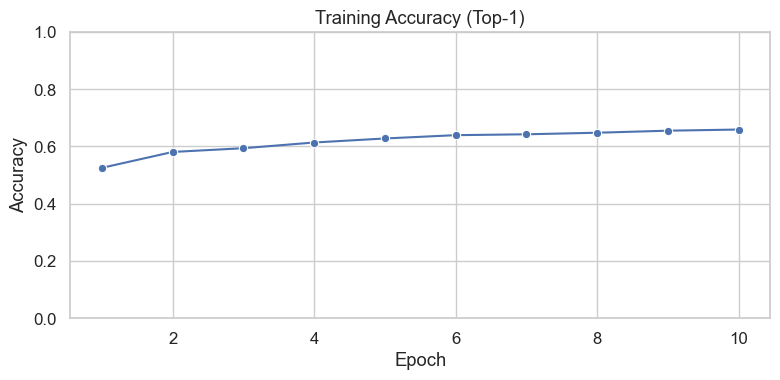

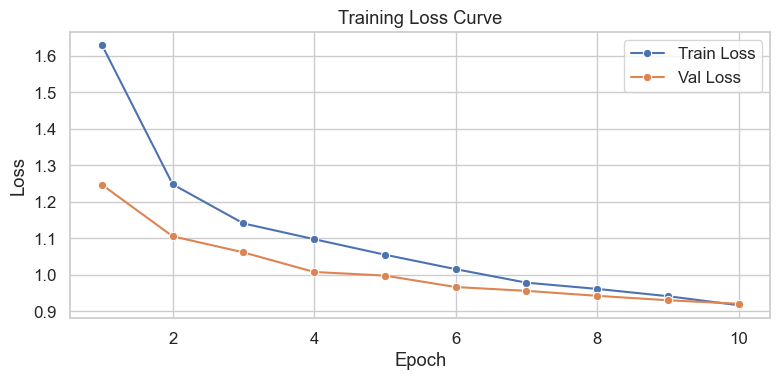

✓ Best Accuracy : 0.6591
✓ Best Epoch   : 10


WindowsPath('training_results.csv')

In [8]:
# ===== SEABORN TRAINING RESULTS VISUALIZATION (ONE CELL) =====

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# IMPORTANT for Jupyter
%matplotlib inline

sns.set_theme(style="whitegrid", font_scale=1.1)

# Locate results.csv
csv_paths = [
    Path("training_results.csv"),
    Path("emotion_runs/emotion_classifier/results.csv")
]

csv_path = None
for p in csv_paths:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("❌ results.csv not found. Train model first.")

print(f"✓ Using training log: {csv_path}")

# Load data
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

# ===================== Accuracy Plot =====================
plt.figure(figsize=(8, 4))
sns.lineplot(
    data=df,
    x="epoch",
    y="metrics/accuracy_top1",
    marker="o"
)
plt.title("Training Accuracy (Top-1)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# ===================== Loss Plot =====================
plt.figure(figsize=(8, 4))
sns.lineplot(
    data=df,
    x="epoch",
    y="train/loss",
    marker="o",
    label="Train Loss"
)

# Validation loss may or may not exist
if "val/loss" in df.columns:
    sns.lineplot(
        data=df,
        x="epoch",
        y="val/loss",
        marker="o",
        label="Val Loss"
    )

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# ===================== Best Epoch Summary =====================
best_idx = df["metrics/accuracy_top1"].idxmax()
best_epoch = int(df.loc[best_idx, "epoch"])
best_acc = df.loc[best_idx, "metrics/accuracy_top1"]

print("=" * 60)
print(f"✓ Best Accuracy : {best_acc:.4f}")
print(f"✓ Best Epoch   : {best_epoch}")
p


## 12. View Training Results CSV

In [9]:
# Display training metrics as a table
import pandas as pd
from pathlib import Path

# Try to find results.csv
csv_paths = [
    Path('training_results.csv'),
    Path('emotion_runs/emotion_classifier/results.csv')
]

csv_path = None
for path in csv_paths:
    if path.exists():
        csv_path = path
        break

if csv_path:
    print("Training Metrics Summary:")
    print("="*60 + "\n")
    
    df = pd.read_csv(csv_path)
    
    # Clean column names (remove extra spaces)
    df.columns = df.columns.str.strip()
    
    # Display first few rows
    print("First 5 epochs:")
    display(df.head())
    
    # Display last few rows
    print("\nLast 5 epochs:")
    display(df.tail())
    
    # Find best epoch
    if 'metrics/accuracy_top1' in df.columns:
        best_idx = df['metrics/accuracy_top1'].idxmax()
        best_acc = df.loc[best_idx, 'metrics/accuracy_top1']
        best_epoch = df.loc[best_idx, 'epoch']
        
        print(f"\n" + "="*60)
        print(f"✓ Best Accuracy: {best_acc:.4f} at Epoch {int(best_epoch)}")
        print("="*60)
else:
    print("⚠ Training results CSV not found!")
    print("Train a model first or copy metrics to root directory.")

Training Metrics Summary:

First 5 epochs:


,epoch,time,train/loss,metrics/accuracy_top1,metrics/accuracy_top5,val/loss,lr/pg0,lr/pg1,lr/pg2
0,1,36.4476,1.62994,0.52536,0.97311,1.24707,0.000302,0.000302,0.000302
1,2,66.6367,1.24818,0.58080,0.98272,1.10580,0.000575,0.000575,0.000575
2,3,96.2506,1.14115,0.59390,0.98579,1.06182,0.000818,0.000818,0.000818
3,4,125.4580,1.09795,0.61382,0.98718,1.00812,0.000774,0.000774,0.000774
4,5,154.9770,1.05547,0.62789,0.98579,0.99829,0.000729,0.000729,0.000729



Last 5 epochs:


,epoch,time,train/loss,metrics/accuracy_top1,metrics/accuracy_top5,val/loss,lr/pg0,lr/pg1,lr/pg2
5,6,183.845,1.01587,0.63945,0.98844,0.96691,0.000684,0.000684,0.000684
6,7,213.314,0.97888,0.64252,0.99136,0.95647,0.000639,0.000639,0.000639
7,8,242.054,0.96180,0.64795,0.99039,0.94279,0.000594,0.000594,0.000594
8,9,270.872,0.94185,0.65506,0.99122,0.93069,0.000549,0.000549,0.000549
9,10,300.017,0.91705,0.65910,0.99136,0.92113,0.000504,0.000504,0.000504



✓ Best Accuracy: 0.6591 at Epoch 10
